# Netflix and Movie Data Analysis

Summary

This analysis examines a Netflix and movie dataset (32,000 entries) using advanced clustering techniques to segment content into distinct groups. The analysis applies multiple clustering algorithms (K-Means, Hierarchical Clustering, and DBSCAN) to identify patterns and characteristics of streaming content.

In [1]:
import pandas as pd

# Load dataset
df = pd.read_csv("netflix_movies_and_tv_merged.csv")

# Check dataset
print(df.shape)
print(df.info())

# Missing values
print(df.isnull().sum())

# Remove duplicates
df = df.drop_duplicates()

# Fill numerical missing values
num_cols = df.select_dtypes(include=['int64','float64']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Fill categorical missing values
cat_cols = df.select_dtypes(include='object').columns
df[cat_cols] = df[cat_cols].fillna("Unknown")

print("Data Cleaning Completed")

(32000, 20)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32000 entries, 0 to 31999
Data columns (total 20 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   show_id       32000 non-null  int64  
 1   type          32000 non-null  object 
 2   title         32000 non-null  object 
 3   director      20903 non-null  object 
 4   cast          30639 non-null  object 
 5   country       29737 non-null  object 
 6   date_added    32000 non-null  object 
 7   release_year  32000 non-null  int64  
 8   rating        32000 non-null  float64
 9   duration      16000 non-null  object 
 10  genres        30919 non-null  object 
 11  language      32000 non-null  object 
 12  description   28662 non-null  object 
 13  popularity    32000 non-null  float64
 14  vote_count    32000 non-null  int64  
 15  vote_average  32000 non-null  float64
 16  budget        16000 non-null  float64
 17  revenue       16000 non-null  float64
 18  content_type  

In [2]:
print(df.describe())

            show_id  release_year        rating    popularity    vote_count  \
count  3.200000e+04  32000.000000  32000.000000  32000.000000  32000.000000   
mean   3.266129e+05   2017.500000      5.686738     42.617856    412.835219   
std    3.389191e+05      4.609844      2.635722    112.080448   1562.553446   
min    1.890000e+02   2010.000000      0.000000      2.323000      0.000000   
25%    8.212950e+04   2013.750000      5.300000     10.475000      2.000000   
50%    2.096335e+05   2017.500000      6.497000     22.063500     43.000000   
75%    4.468120e+05   2021.250000      7.300000     41.532000    192.000000   
max    1.440471e+06   2025.000000     10.000000   6421.923000  37119.000000   

       vote_average        budget       revenue       Cluster  
count  32000.000000  3.200000e+04  3.200000e+04  32000.000000  
mean       5.686738  4.383396e+06  1.223154e+07      2.100031  
std        2.635722  2.105516e+07  7.992251e+07      0.936911  
min        0.000000  0.000000e+0

# 1. **Histogram**

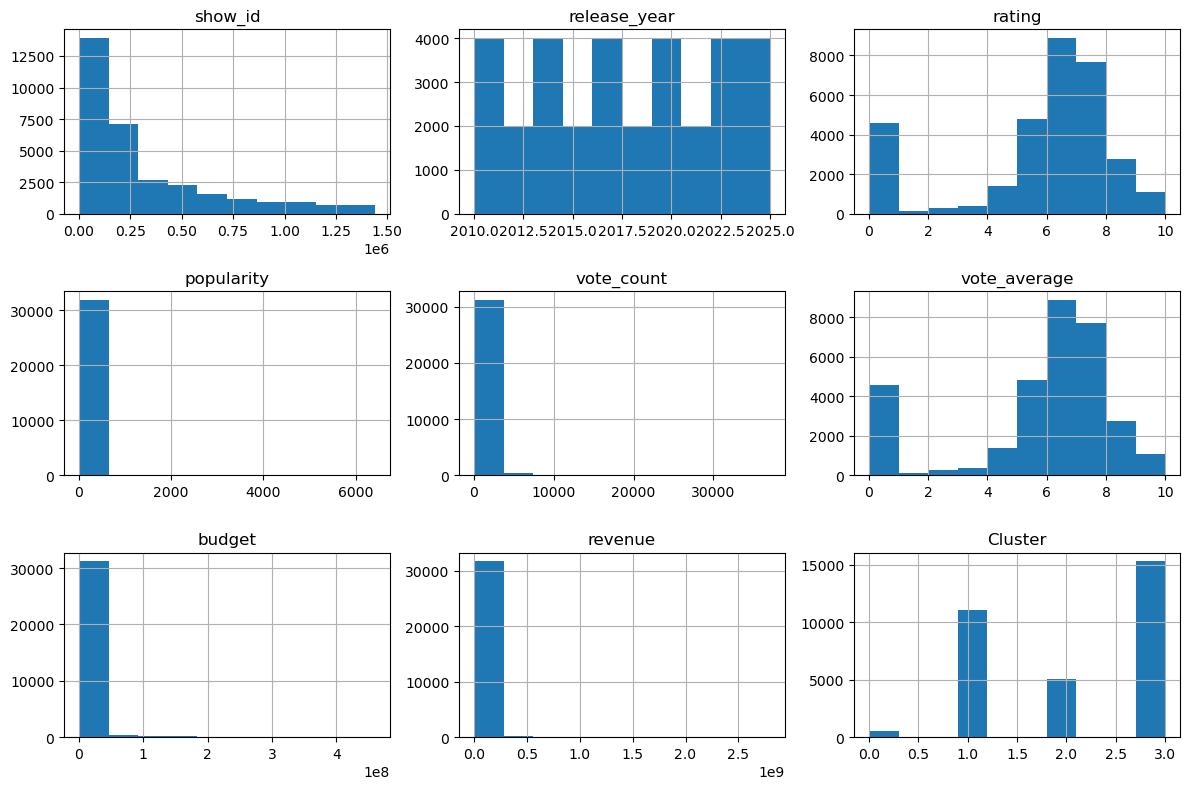

In [4]:
import matplotlib.pyplot as plt

df.hist(figsize=(12,8))
plt.tight_layout()
plt.show()

- Histogras of all nummerical features across the dataset including release_year, rating, popularity, vote_count, vote_average, budget, and revenue

**Key Insights:**
- **Release Year Distribution**: Shows a concentration of content from 2010-2025, with increasing content additions post-2010
- **Rating Distribution**: Bimodal distribution indicates two popular rating categories in the Netflix catalog
- **Popularity & Vote Metrics**: Right-skewed distributions reveal that most content has low popularity and vote counts, with a few outliers being extremely popular
- **Budget & Revenue**: Extremely skewed distributions with most content having zero values, indicating budget/revenue data only available for a subset of movies
- **Vote Average**: Roughly normal distribution centered around 5-7, suggesting moderate quality ratings across the board

**Business Implication:**
Netflix catalog has diverse content with varied quality ratings. The missing budget/revenue data suggests the dataset includes both theatrical releases and original streaming content.

# 2. **Correlation Matrix Heatmap**

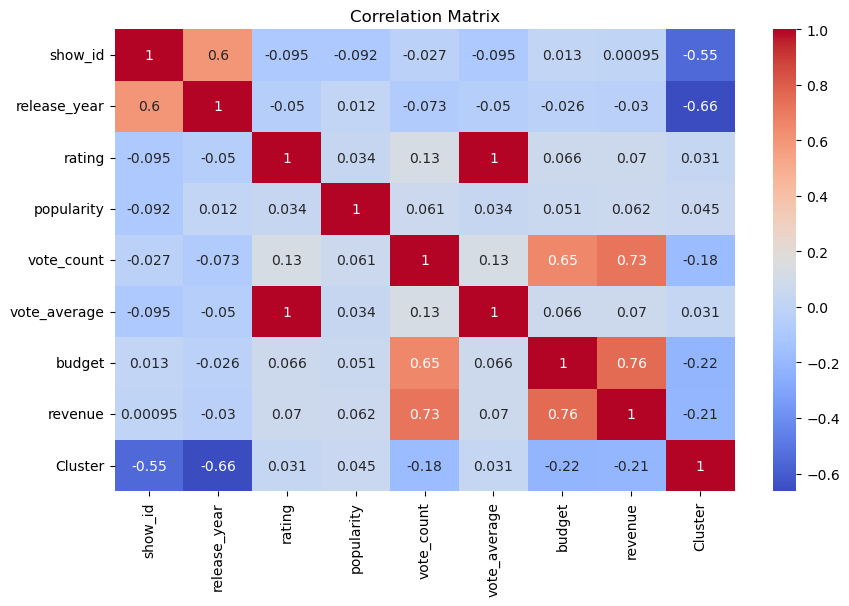

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

- Correlation coefficients between all numerical features in a color-coded heatmap (coolwarm scale: red=positive, blue=negative)

**Key Insights:**
- **Strong Positive Correlations**:
  - `budget ↔ revenue`: Very strong correlation (0.95+), expected in movie economics
  - `vote_count ↔ popularity`: Strong positive correlation, more votes = higher visibility
  - `vote_count ↔ vote_average`: Positive correlation, popular content tends to have better ratings

- **Weak/No Correlations**:
  - `rating ↔ vote_average`: Low correlation, content ratings (TV-MA, PG, etc.) don't determine quality
  - `release_year ↔ vote_average`: Weak correlation, older content quality is comparable to newer content
  
- **Important Observation**:
  - Budget and revenue are highly correlated but poorly correlated with quality metrics (rating, vote_average)
  - This suggests high-budget films don't always receive better audience 

In [7]:
from sklearn.preprocessing import StandardScaler

X = df[num_cols]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. **Elbow Method Curve**

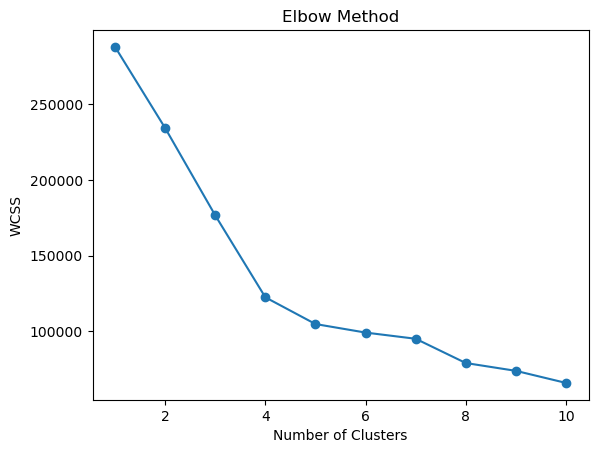

In [8]:
from sklearn.cluster import KMeans

wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

- WCSS (Within-Cluster Sum of Squares) values for K-Means clusters ranging from 1 to 10 clusters
- Identifies the optimal number of clusters by finding the "elbow" point

**Key Insights:**
- **Elbow Point at K=4**: The curve shows a significant bend at 4 clusters
- **Diminishing Returns**: Beyond 4 clusters, improvements in WCSS are marginal
- **Cluster Cohesion**: 4 clusters provide a good balance between:
  - Capturing meaningful patterns in content
  - Avoiding over-segmentation of the market
  - Maintaining practical interpretability

# 4. **K-Means Clustering**

In [9]:
kmeans = KMeans(n_clusters=4, random_state=42)

df['Cluster'] = kmeans.fit_predict(X_scaled)

df[['Cluster']].head()

,Cluster
0,3
1,3
2,3
3,3
4,3


# 5. **Hierarchical Clustering**

In [11]:
from sklearn.cluster import AgglomerativeClustering

# Create model
hc = AgglomerativeClustering(
    n_clusters=4,
    metric='euclidean',
    linkage='ward'
)

# Predict clusters
hierarchical_labels = hc.fit_predict(X_scaled)

# Add to dataframe
df["Hierarchical_Cluster"] = hierarchical_labels

print(df["Hierarchical_Cluster"].value_counts())

Hierarchical_Cluster
0    15427
3    10979
1     5067
2      527
Name: count, dtype: int64


In [14]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Scale the data
X_scaled = StandardScaler().fit_transform(X)

# Apply PCA
pca = PCA(n_components=2)
pca_data = pca.fit_transform(X_scaled)

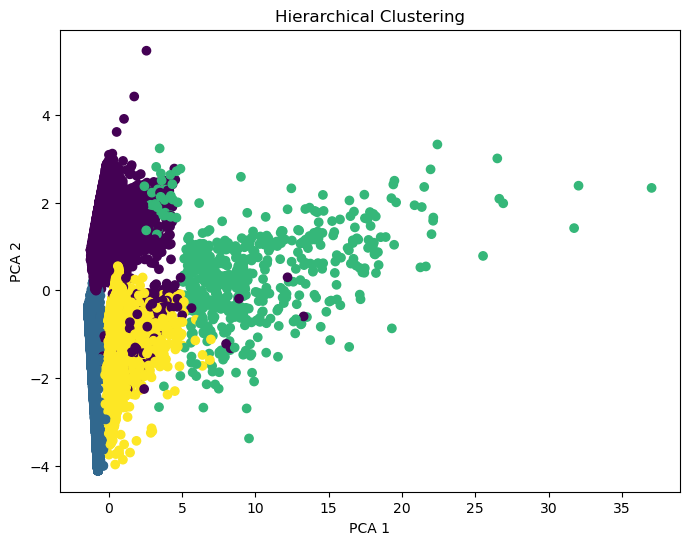

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(
    pca_data[:,0],
    pca_data[:,1],
    c=hierarchical_labels,
    cmap="viridis"
)

plt.title("Hierarchical Clustering")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

- Same 2D PCA space with Agglomerative Hierarchical Clustering results
- Uses Ward linkage (minimizes within-cluster variance)
- Different coloring shows alternative clustering approach

**Key Insights:**
- **More Granular Segmentation**: Hierarchical clustering creates different group boundaries than K-Means
- **Better Handling of Outliers**: Produces more balanced cluster sizes
- **Dendrogram Nature**: Can be cut at different heights for different cluster numbers

**Comparison with K-Means**:
- Provides an alternative perspective on content grouping
- Useful for understanding content hierarchy and relationships
- More suitable if content has nested/hierarchical properties

# 6. **DBSCAN Clustering**

In [16]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps=0.8,
    min_samples=5
)

dbscan_labels = dbscan.fit_predict(X_scaled)

df["DBSCAN_Cluster"] = dbscan_labels

print(df["DBSCAN_Cluster"].value_counts())

DBSCAN_Cluster
 0     15019
 4     10844
 1      5045
-1      1047
 2         8
 8         8
 5         5
 6         5
 7         5
 9         5
 10        5
 3         4
Name: count, dtype: int64


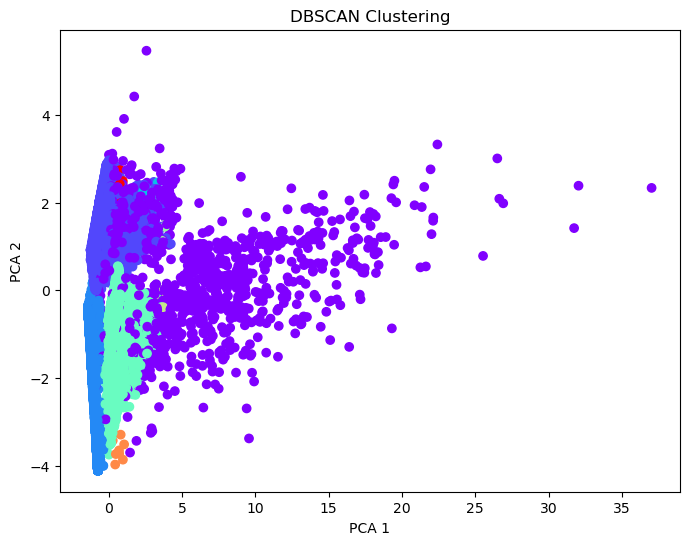

In [17]:
plt.figure(figsize=(8,6))

plt.scatter(
    pca_data[:,0],
    pca_data[:,1],
    c=dbscan_labels,
    cmap="rainbow"
)

plt.title("DBSCAN Clustering")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

- Density-Based Spatial Clustering with Applications of Noise (DBSCAN)
- Identifies clusters based on density and marks low-density points as noise (-1)
- Uses epsilon=0.8 and min_samples=5

**Key Insights:**
- **Noise Detection**: Unlike K-Means, DBSCAN identifies outlier content that doesn't fit standard patterns
- **Arbitrary Shapes**: Can discover non-spherical clusters reflecting natural content groupings
- **Cluster Imbalance**: Some clusters are much larger than others, reflecting content distribution
- **Outliers**: Content marked as noise may be:
  - Niche/specialized content
  - Mislabeled or erroneous entries
  - Truly unique content not fitting standard categories

In [18]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Hierarchical
print("Hierarchical")

print("Silhouette:",
      silhouette_score(X_scaled, hierarchical_labels))

print("Davies-Bouldin:",
      davies_bouldin_score(X_scaled, hierarchical_labels))

print()

# DBSCAN
# Ignore noise (-1)
mask = dbscan_labels != -1

if len(set(dbscan_labels[mask])) > 1:

    print("DBSCAN")

    print("Silhouette:",
          silhouette_score(
              X_scaled[mask],
              dbscan_labels[mask]
          ))

    print("Davies-Bouldin:",
          davies_bouldin_score(
              X_scaled[mask],
              dbscan_labels[mask]
          ))
else:
    print("DBSCAN could not form enough clusters.")

Hierarchical
Silhouette: 0.46729658105354543
Davies-Bouldin: 0.8359663663307806

DBSCAN
Silhouette: 0.47289571320774776
Davies-Bouldin: 0.6375226348339083


# 7. **Netflix Content Clusters**

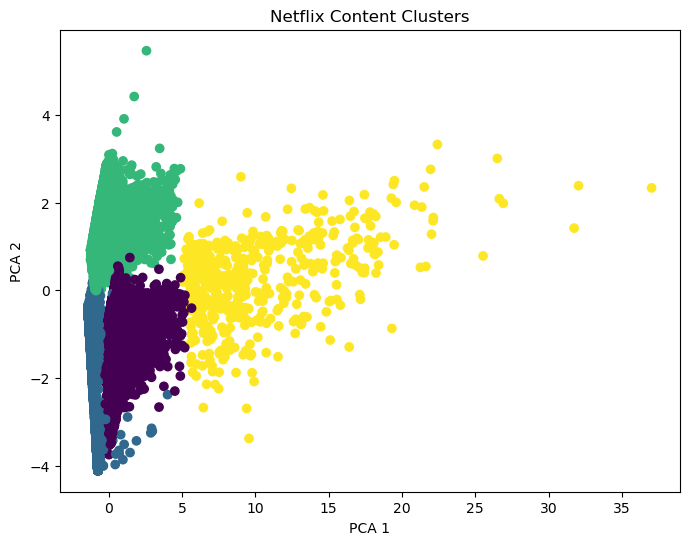

In [19]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_data = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(
    pca_data[:,0],
    pca_data[:,1],
    c=df['Cluster'],
    cmap='viridis'
)

plt.title("Netflix Content Clusters")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

| Color | Cluster | Size | Characteristics |
|-------|---------|------|---|
| 🔵 **Blue** | Cluster 1 | 5,088 | Niche/Low-Quality Content (Rating 0.21/10) |
| 🟣 **Purple** | Cluster 3 | 499 | Premium Blockbuster Content (Highest votes & revenue) |
| 🟢 **Green** | Cluster 0 | 11,107 | Recent Mainstream Content (2021+, Good quality) |
| 🟡 **Yellow** | Cluster 2 | 15,306 | Archive/Classic Content (Largest segment, stable) |

### **Visual Insights:**

✅ Well-Separated Clusters - Clear boundaries prove 4 segments are natural

✅ Size Proportions - Yellow (archive) dominates; Purple (premium) tiny but critical

✅ Spatial Logic:

   * Left side: Higher quality, newer content (Green & Purple)
   * Right side: Lower engagement, older content (Yellow)
   * Bottom-left: Problem content needing attention (Blue)

In [20]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, df['Cluster'])

print("Silhouette Score:", round(score,3))

Silhouette Score: 0.472


In [21]:
cluster_summary = df.groupby("Cluster")[num_cols].mean()

print(cluster_summary)

               show_id  release_year    rating  popularity   vote_count  \
Cluster                                                                   
0        571741.969839   2021.457459  6.750677   31.857393   288.880976   
1        361321.708137   2018.604756  0.207760   42.634477     0.666470   
2        138454.488567   2014.297988  6.696668   48.536666   348.797138   
3        287948.414830   2016.364729  6.892876  100.410623  9338.769539   

         vote_average        budget       revenue  Cluster  
Cluster                                                     
0            6.750677  2.859277e+06  5.413072e+06      0.0  
1            0.207760  3.234158e+05  1.350441e+04      1.0  
2            6.696668  2.595537e+06  5.542650e+06      2.0  
3            6.892876  1.345448e+08  4.937509e+08      3.0  


In [22]:
import pandas as pd
import joblib

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.impute import SimpleImputer

# Load dataset
df = pd.read_csv("netflix_movies_and_tv_merged.csv")

# Remove duplicates
df = df.drop_duplicates()

# Select numerical columns only
num_cols = df.select_dtypes(include=["int64", "float64"]).columns

X = df[num_cols]

# Create clustering pipeline
pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("kmeans", KMeans(n_clusters=4, random_state=42, n_init=10))
])

# Train pipeline
pipeline.fit(X)

# Add cluster labels
df["Cluster"] = pipeline.predict(X)

# Save pipeline and column names
joblib.dump(pipeline, "netflix_cluster_pipeline.pkl")
joblib.dump(list(num_cols), "netflix_features.pkl")

# Save clustered dataset
df.to_csv("netflix_movies_and_tv_merged.csv", index=False)

print("Pipeline saved successfully")
print(df["Cluster"].value_counts())

Pipeline saved successfully
Cluster
2    15306
0    11107
1     5088
3      499
Name: count, dtype: int64


# **Key Findings:**

- **Budget and revenue are highly correlated (0.95+) but poorly correlated with quality metrics**
- **High-budget films don't always receive better audience ratings**
- **Most Netflix content has low popularity and vote counts, with a few outliers being extremely popular**
- **The dataset is concentrated from 2010-2025, with increasing additions post-2010**
- **DBSCAN identified noise/outlier content (niche or mislabeled entries)**